# Music Genre Classification with Machine Learning

# Introduction
**Music Information Retrieval** (MIR) is the interdisciplinary science of retrieving information from music. It is used across a number of fields, by both businesses and academics, to categorize, manipulate, and even create music - powering applications such as music recommendation systems, music source separation, instrument recognition, and music generation, among others. This project focuses on one such application, **music genre classification**, and uses it as a benchmark to compare the predictive accuracy of three approaches: the **K-Nearest Neighbours** algorithm, an **Artificial Neural Network**, and a **Convolutional Neural Network**.

# Project Description
The aim of this project is to implement and compare the accuracy of three approaches to music genre classification: the K-Nearest Neighbours (kNN) algorithm, an Artificial Neural Network (ANN), and a Convolutional Neural Network (CNN). The kNN and ANN models are trained on the same tabular data, part of which was extracted manually, while the CNN is trained on the spectrogram images provided with the dataset.
For each model, a range of hyperparameters is explored through randomized search, and the best-performing configuration is evaluated in detail using accuracy scores and confusion matrices. The goal is to identify which of the three models performs best on this task.
The expected results are that kNN, being the simplest algorithm, will perform the worst, while the ANN and CNN, being Neural Networks and therefore more complex will perform better, the CNN in particular is expectedd to perform best.

# Data
The dataset used for this project is **GTZAN**, a popular benchmark dataset in the music genre classification field. It consists of *1,000 audio* tracks, each *30 seconds long*, evenly distributed across 10 genres: blues, classical, country, disco, hip-hop, jazz, metal, pop, reggae, and rock. Alongside the raw audio, the dataset also includes pre-computed *mel spectrograms* for each track, as well as *two CSV* files containing numerical features extracted from the audio.
### Importing GTZAN

In [69]:
import os # to interact with OS file/directory opeartions ..
import platform

OS = platform.system()
 # these 4 were added to prevent the python kernel from dying when training the models.
 # I believe they limit the performance but at least I could get work done
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"        
os.environ["MKL_NUM_THREADS"] = "1"        
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

### Defining path to Dataset

if OS == "Windows":
    PATH = "C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\genres_original"
    PATH_CSV_30 = "C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\features_30_sec.csv"
    PATH_CSV_3 = "C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\features_3_sec.csv"
    PATH_IMAGES = "C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original"
if OS == "Linux":
    PATH = "/home/ket/Documents/gtzan/archive/Data/genres_original"
    PATH_CSV_30 = "/home/ket/Documents/gtzan/archive/Data/features_30_sec.csv"
    PATH_CSV_3 = "/home/ket/Documents/gtzan/archive/Data/features_3_sec.csv"
    PATH_IMAGES = "/home/ket/Documents/gtzan/archive/Data/images_original"

## Audio Features
For the kNN and ANN models, this project uses numerical audio features - both the ones already provided and additional ones *extracted manually* - rather than the raw audio. These features are available in the included CSV files, both of which contain the *mean* and *variance* of the following: `Short-Time Fourier Transform Chromagram`, `Root Mean Square`, `Spectral Centroid`, `Spectral Bandwidth`, `Roll-off`, `Zero Crossing Rate`, `Harmony`, `Tempo`, and `Mel-Frequency Cepstral Coefficients` (MFCCs).
The two CSV files differ in how the underlying audio was segmented before extraction: in the first, features were *extracted directly from the full 30-second tracks*, while in the second, *each track was first split into 3-second segments*, increasing the number of available samples tenfold.

In [70]:
import pandas as pd # just used to import the csvs. dataframe manipulation (csv/excel)

df_30 = pd.read_csv(PATH_CSV_30)
df_3 = pd.read_csv(PATH_CSV_3)

#df_30.columns # 60 COLUMNS
# df_30.isnull().sum() # no null values
# df_30.info()
# df_30.describe
# pandas quickstart: https://github.com/techwithtim/PanadasTutorial

## Spectrograms
For the CNN, this project uses the pre-computed mel spectrograms included with the dataset - a visual, image-based representation of each audio track's frequency content over time — since the CNN classifies data through image representation rather than tabular features.

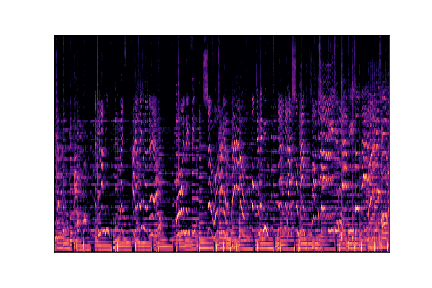

In [71]:
# show an example spectrogram pop 12
from IPython.display import Image

example_spectrogram = os.path.join(PATH_IMAGES,"pop", "pop00012.png")
Image(filename=example_spectrogram)     

# Data preprocessing
The dataset was imported, after which it was necessary to determine which of the included columns were actually relevant. Of the 60 columns present, `filename` was *removed*, as it holds no predictive value, while all *the rest were kept*, `label` being key, since it holds the genre which is the target variable for classification.

This is however done individually at each step that requires it, instead of once at the beginning.

## Feature extraction
To extract features from the raw audio files manually, the `AudioFeaturizer` library was used. The resulting output does not match the pre-extracted dataset features one-to-one, as it only extracts the *mean* and not also the *variance*; it was however deemed sufficiently comparable for the purposes of this project.
It is worth noting that one of the original audio files appears to be **corrupted**, as no features could be extracted from it. This issue is also documented on the dataset's Kaggle page. The affected file is `jazz.00054.wav`.

In [72]:
from AudioFeaturizer.audio_featurizer import *

# test =audio_process("/home/ket/Documents/gtzan/archive/Data/genres_original/jazz/jazz.00055.wav")
# print(type(test))
# print("Genres: ", genres)

genres = os.listdir(PATH)
results = []

    # COMMENTED SO IT DOESNT EXTRACT FEATURES EVERY TIME
if not os.path.exists("extracted-features.csv"):
    for genre in tqdm(genres, desc="Feature exctraction"):
        genre_path = os.path.join(PATH, genre)
        for filename in os.listdir(genre_path):
            if(filename != "jazz.00054.wav"): # broken
                file_path = os.path.join(genre_path, filename)

                try:
                    features = audio_process(file_path)
                    row = features.iloc[0].to_dict()
                    row["genre"] = genre
                    row["filename"] = filename
                    results.append(row)
                except Exception as e:
                    print("[Error]: Something went wrong")

    extr_df = pd.DataFrame(results)
    extr_df.to_csv("extracted-features.csv", index=False)
print("File [extracted-features.csv] detected.")
extr_df = pd.read_csv("extracted-features.csv")


File [extracted-features.csv] detected.


### Correlation heatmap
Correlation heatmaps are generally generated *before* model training begins, as they help visualize the relationships between input features. Specifically, they show the degree to which features correlate with each other. A high correlation between two features suggests redundancy, since they likely carry much of the same information.
The heatmap for this project is handled by `Seaborn`, and drawn with `Matplotlib`.

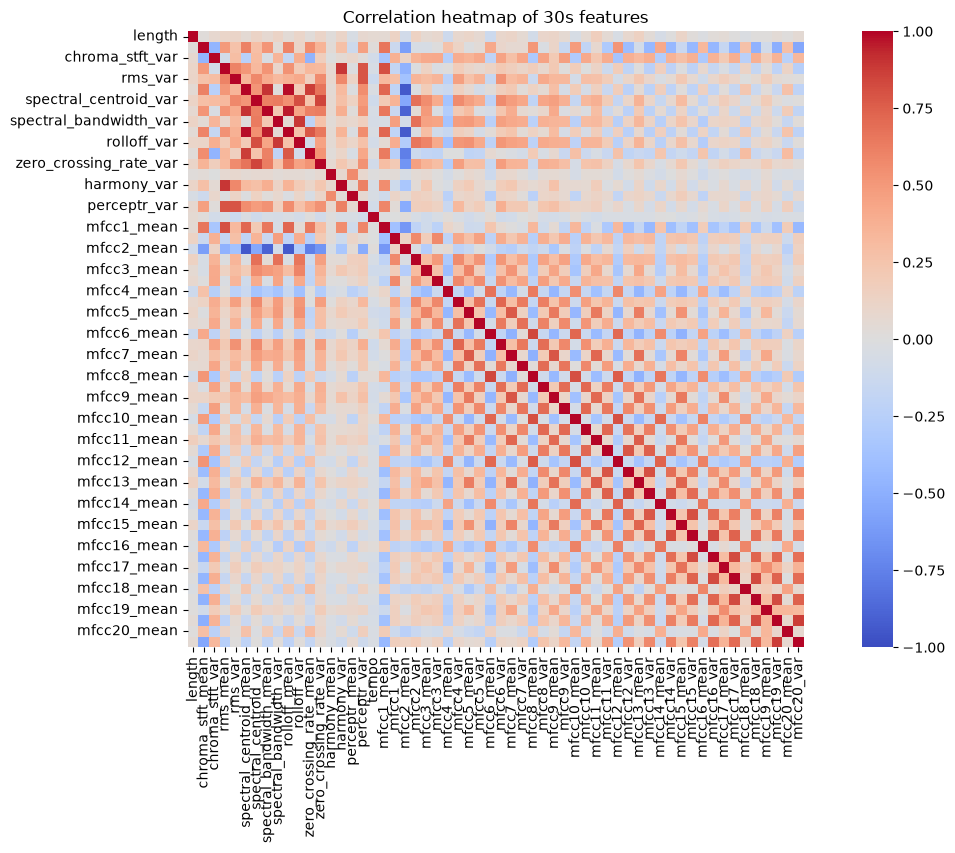

In [73]:
import seaborn as sb
import matplotlib.pyplot as plt

corr_30 = df_30.drop(columns=["label","filename"]).corr()
corr_3 = df_3.drop(columns=["label", "filename"]).corr()
corr_extr = extr_df.drop(columns=["genre", "filename"]).corr()

plt.figure(figsize=(15, 8))
sb.heatmap(corr_30, cmap="coolwarm", vmin=-1, vmax=1, center=0, annot=False, square=True)
plt.title("Correlation heatmap of 30s features"); plt.show()

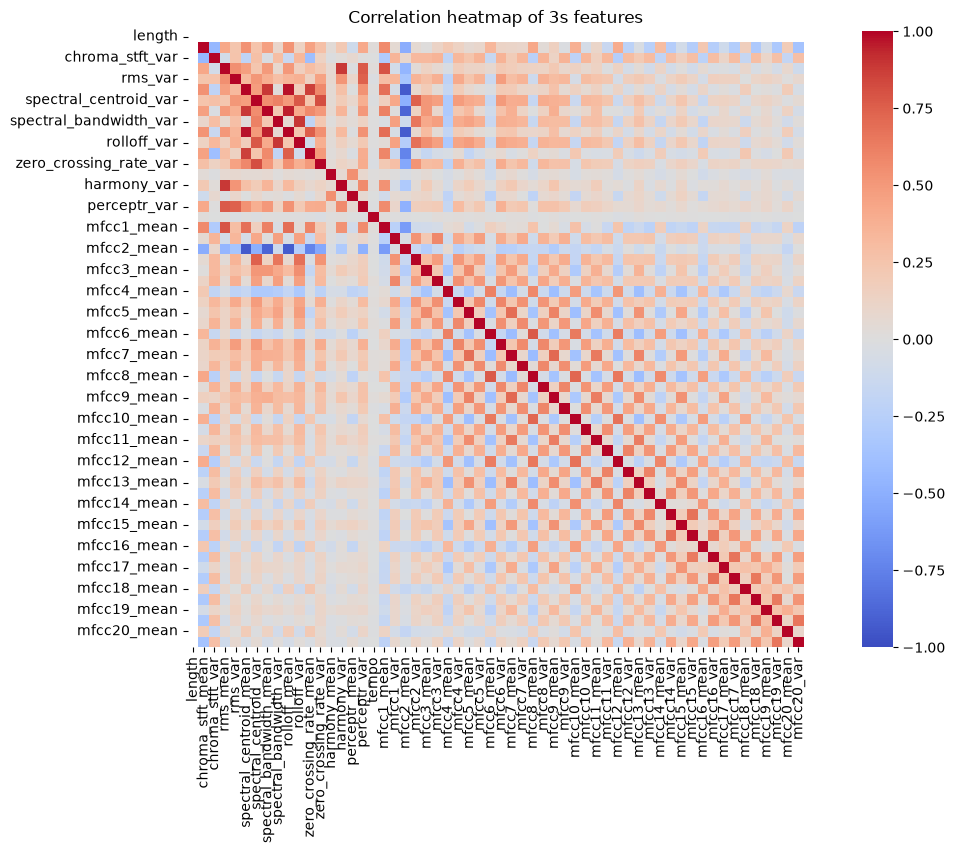

In [74]:
plt.figure(figsize=(15, 8))
sb.heatmap(corr_3, cmap="coolwarm",vmin=-1, vmax=1, center=0, annot=False, square=True)
plt.title("Correlation heatmap of 3s features"); plt.show()

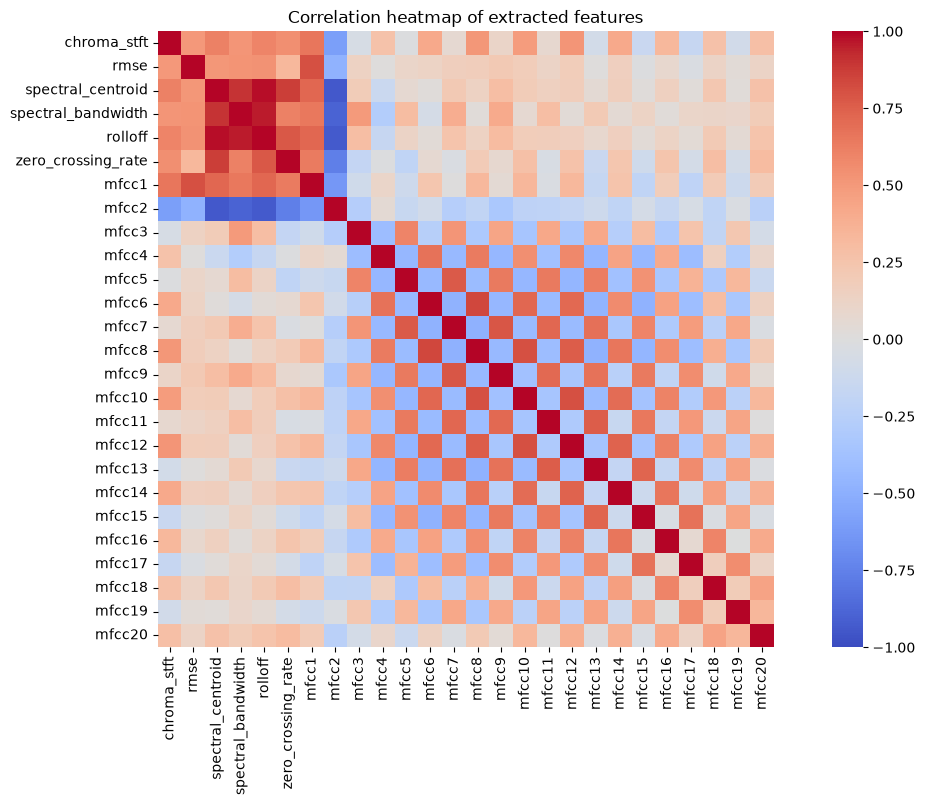

In [75]:
plt.figure(figsize=(15, 8))
sb.heatmap(corr_extr, cmap="coolwarm", vmin=-1, vmax=1, center=0, annot=False, square=True)
plt.title("Correlation heatmap of extracted features"); plt.show()

The diagonal line line across the grid simply indicates that the specific variable is correlating highly with each other, which makes sense, since the carry the same information. In each of the heatmaps is observed that in the top left corner, a number of features correlates rather highly with one another. The observation is even more apparent in the heatmap of the extracted features which only has roughly half of the features of the the other two. Despite these observations, none of the columns were dropped.

# kNN
K-Nearest Neighbours is a simple machine learning algorithm widely used for classification and regression tasks. It works by identifying the K closest data points to a given input and predicting a class based on the majority vote (or, for regression, the average value) among those neighbours.
The approach taken with kNN was to explore a *range* of hyperparameter values in order to identify the combination that yields the highest accuracy, and then examine that configuration more closely. Data collection was automated, with the following parameters varied across runs: the number of MFCCs used, the number of neighbours (k) considered, the test size, and the random seed used for the train/test split.
Although data was also collected for test sizes of `0.1` and `0.2`, these were excluded from the final accuracy readings, as the resulting test sets were likely too small to give a reliable estimate of performance given the overall size of the dataset.
## kNN - 30s

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from tqdm import tqdm

### variables
MFCC_N = 20
K_N = 30
TEST_SIZE = [0.1, 0.2, 0.3, 0.4]
RANDOM_STATE = [0, 42, 99]
CSV_PATH_KNN_30 = "knn-data-df-30.csv"
###


#omega loop to collect all the possible variations
if not os.path.exists(CSV_PATH_KNN_30):
    results = []

    df_base = df_30.copy()
    col = df_base.pop("label")
    df_base.insert(0, "label", col)
    df_base.drop("filename", inplace=True, axis=1)

    for i in tqdm(range(1, MFCC_N+1), desc="kNN Data collection progress"):       
        print("We're at MFCC: ", MFCC_N)
        df_work = df_base.copy()

        for n in range(20 - i):
            df_work.drop(f"mfcc{20-n}_var", inplace=True, axis=1)
            df_work.drop(f"mfcc{20-n}_mean", inplace=True, axis=1)

        X = df_work.drop(columns=["label"])
        y = df_work["label"]
        X_scaled = StandardScaler().fit_transform(X)

        for k in tqdm(range(1, K_N+1), desc="K-Neighbors", leave=False):      
            for test_size in tqdm(TEST_SIZE, desc="Test size", leave=False):
                for seed in tqdm(RANDOM_STATE, desc="seed", leave=False): 
                    
                    # col = df_work.pop("label")
                    # df_work.insert(0, "label", col)
                    # df_work.drop("filename", inplace=True, axis=1)        

                    X_train, X_test, y_train, y_test = train_test_split(
                        X_scaled, y, test_size=test_size, random_state=seed, stratify=y
                    )

                    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
                    acc = knn.score(X_test, y_test)

                    results.append({"MFCC_N": i, "K_N": k, "TEST_SIZE": test_size,
                                    "RANDOM_STATE": seed, "ACCURACY": acc})


    pd.DataFrame(results).to_csv(CSV_PATH_KNN_30, index=False)
print("File [", CSV_PATH_KNN_30,"] detected.")


File [ knn-data-df-30.csv ] detected.


In [77]:
df_knn_extract = pd.read_csv("knn-data-df-30.csv")
df_knn_extract = df_knn_extract[df_knn_extract["TEST_SIZE"]!= 0.1]
df_knn_extract = df_knn_extract[df_knn_extract["TEST_SIZE"]!= 0.2]
df_knn_extract = df_knn_extract[df_knn_extract["K_N"] != 1]
df_knn_30_sorted = df_knn_extract.sort_values(by="ACCURACY", ascending=False)

df_knn_30_sorted.head(10)

,MFCC_N,K_N,TEST_SIZE,RANDOM_STATE,ACCURACY
5454,16,5,0.3,0,0.726667
5095,15,5,0.3,42,0.720000
6162,18,4,0.3,0,0.720000
5795,17,3,0.4,99,0.720000
4002,12,4,0.3,0,0.716667
4710,14,3,0.3,0,0.716667
5814,17,5,0.3,0,0.716667
5083,15,4,0.3,42,0.716667
5479,16,7,0.3,42,0.716667
6875,20,3,0.4,99,0.715000


## kNN - 3s

In [78]:
# ~22 minutes
### variables
MFCC_N = 20
K_N = 30
TEST_SIZE = [0.1, 0.2, 0.3, 0.4]
RANDOM_STATE = [0, 42, 99]
CSV_PATH_KNN_3 = "knn-data-df-3.csv"
# ###


# #omega loop to collect all the possible variations
if not os.path.exists(CSV_PATH_KNN_3):
    
    results = []

    df_base = df_3.copy()
    col = df_base.pop("label")
    df_base.insert(0, "label", col)
    df_base.drop("filename", inplace=True, axis=1)

    for i in tqdm(range(1, MFCC_N+1), desc="kNN Data collection progress"):       
        print("We're at MFCC: ", MFCC_N)
        df_work = df_base.copy()

        for n in range(20 - i):
            df_work.drop(f"mfcc{20-n}_var", inplace=True, axis=1)
            df_work.drop(f"mfcc{20-n}_mean", inplace=True, axis=1)

        X = df_work.drop(columns=["label"])
        y = df_work["label"]
        X_scaled = StandardScaler().fit_transform(X)

        for k in tqdm(range(1, K_N+1), desc="K-Neighbors", leave=False):      
            for test_size in tqdm(TEST_SIZE, desc="Test size", leave=False):
                for seed in tqdm(RANDOM_STATE, desc="seed", leave=False): 
                    
                    # col = df_work.pop("label")
                    # df_work.insert(0, "label", col)
                    # df_work.drop("filename", inplace=True, axis=1)        

                    X_train, X_test, y_train, y_test = train_test_split(
                        X_scaled, y, test_size=test_size, random_state=seed, stratify=y
                    )

                    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
                    acc = knn.score(X_test, y_test)

                    results.append({"MFCC_N": i, "K_N": k, "TEST_SIZE": test_size,
                                    "RANDOM_STATE": seed, "ACCURACY": acc})


    pd.DataFrame(results).to_csv(CSV_PATH_KNN_3, index=False)

print("File [", CSV_PATH_KNN_3,"] detected.")


File [ knn-data-df-3.csv ] detected.


In [79]:
df_knn_3 = pd.read_csv("knn-data-df-3.csv")
df_knn_3 = df_knn_3[df_knn_3["TEST_SIZE"]!= 0.1]
df_knn_3 = df_knn_3[df_knn_3["TEST_SIZE"]!= 0.2]
df_knn_3 = df_knn_3[df_knn_3["K_N"] != 1]
df_knn_3_sorted = df_knn_3.sort_values(by="ACCURACY", ascending=False)

df_knn_3_sorted.head(10)

,MFCC_N,K_N,TEST_SIZE,RANDOM_STATE,ACCURACY
5430,16,3,0.3,0,0.889223
6870,20,3,0.3,0,0.888222
5790,17,3,0.3,0,0.888222
4710,14,3,0.3,0,0.887888
5070,15,3,0.3,0,0.886887
6882,20,4,0.3,0,0.883550
6510,19,3,0.3,0,0.882883
6150,18,3,0.3,0,0.882549
6872,20,3,0.3,99,0.882549
4350,13,3,0.3,0,0.882216


## kNN - extracted features

In [80]:
### variables
MFCC_N = 20
K_N = 30
TEST_SIZE = [0.1, 0.2, 0.3, 0.4]
RANDOM_STATE = [0, 42, 99]
CSV_PATH_KNN_EXTR = "knn-extracted-features.csv"
###


#omega loop to collect all the possible variations
if not os.path.exists(CSV_PATH_KNN_EXTR):

    results = []

    df_base = extr_df.copy()
    col = df_base.pop("genre")
    df_base.insert(0, "genre", col)
    df_base.drop("filename", inplace=True, axis=1)
    #

    for i in tqdm(range(1, MFCC_N+1), desc="kNN Data collection progress"):       
        print("We're at MFCC: ", MFCC_N)
        df_work = df_base.copy()

        for n in range(20 - i):
            df_work.drop(f"mfcc{20-n}", inplace=True, axis=1)

        X = df_work.drop(columns=["genre"])
        y = df_work["genre"]
        X_scaled = StandardScaler().fit_transform(X)

        for k in tqdm(range(1, K_N+1), desc="K-Neighbors", leave=False):      
            for test_size in tqdm(TEST_SIZE, desc="Test size", leave=False):
                for seed in tqdm(RANDOM_STATE, desc="seed", leave=False): 
                    
                    # col = df_work.pop("label")
                    # df_work.insert(0, "label", col)
                    # df_work.drop("filename", inplace=True, axis=1)        

                    X_train, X_test, y_train, y_test = train_test_split(
                        X_scaled, y, test_size=test_size, random_state=seed, stratify=y
                    )

                    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
                    acc = knn.score(X_test, y_test)

                    results.append({"MFCC_N": i, "K_N": k, "TEST_SIZE": test_size,
                                    "RANDOM_STATE": seed, "ACCURACY": acc})


    pd.DataFrame(results).to_csv(CSV_PATH_KNN_EXTR, index=False)

print("File [", CSV_PATH_KNN_EXTR,"] detected.")


File [ knn-extracted-features.csv ] detected.


In [81]:
df_knn_extract = pd.read_csv("knn-extracted-features.csv")
df_knn_extract = df_knn_extract[df_knn_extract["TEST_SIZE"]!= 0.1]
df_knn_extract = df_knn_extract[df_knn_extract["TEST_SIZE"]!= 0.2]
df_knn_extract = df_knn_extract[df_knn_extract["K_N"] != 1]
df_knn_extract_sorted = df_knn_extract.sort_values(by="ACCURACY", ascending=False)

df_knn_extract_sorted.head(10)

,MFCC_N,K_N,TEST_SIZE,RANDOM_STATE,ACCURACY
5826,17,6,0.3,0,0.673333
6210,18,8,0.3,0,0.666667
5814,17,5,0.3,0,0.663333
5454,16,5,0.3,0,0.663333
6546,19,6,0.3,0,0.663333
6186,18,6,0.3,0,0.663333
6222,18,9,0.3,0,0.660000
6618,19,12,0.3,0,0.660000
6522,19,4,0.3,0,0.660000
6534,19,5,0.3,0,0.660000


It would appear that the missing variance columns in the extracted features does indeed impact accuracy by ~5%.
The below code simply generates the confusion matrices that will be analyzed later.

Accuracy: 0.6733333333333333


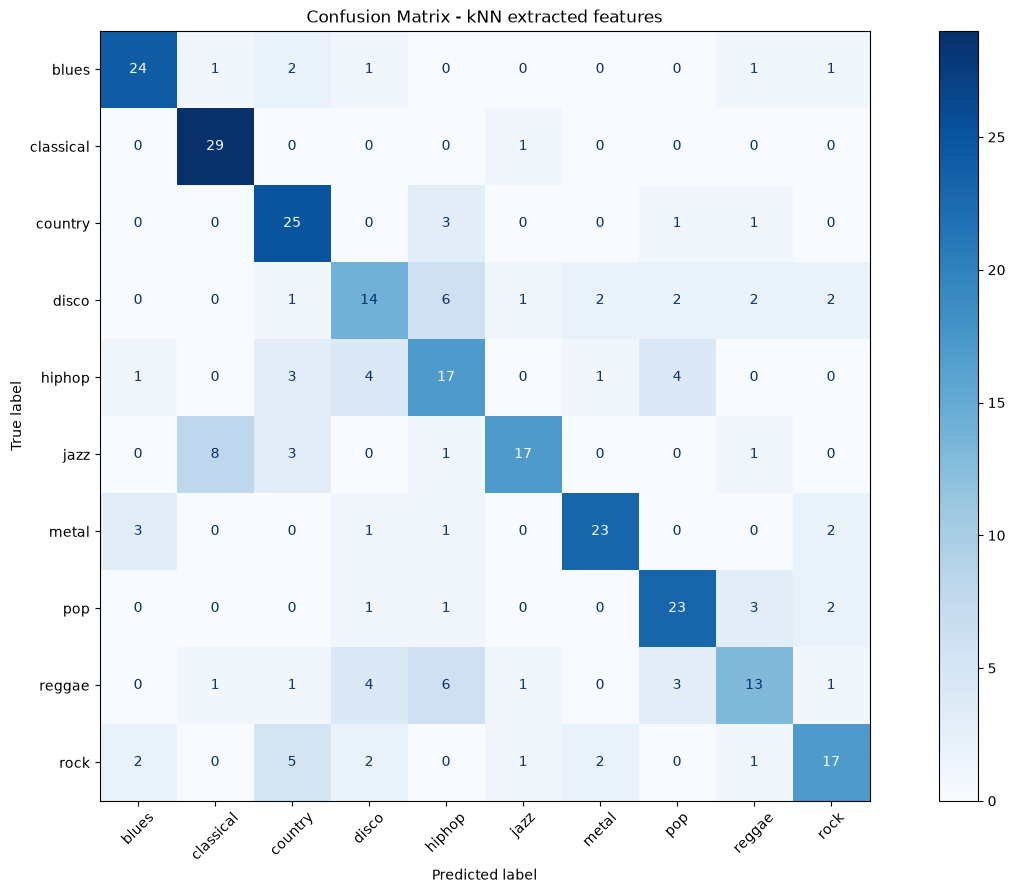

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# MFCC_N	K_N	TEST_SIZE	RANDOM_STATE	ACCURACY
# 3s
# 16    	3   	0.3     	0       	0.889223
# MFCC_N = 16; K_N = 3; TEST_SIZE = 0.3; RANDOM_STATE = 0
# 30s
# 16    	5   	0.3     	0	        0.726667
# MFCC_N = 16; K_N = 5; TEST_SIZE = 0.3; RANDOM_STATE = 0
# extracted
# 17	    6      	0.3     	0	0       .673333
MFCC_N = 17; K_N = 6; TEST_SIZE = 0.3; RANDOM_STATE = 0

###


df_base = extr_df.copy()
col = df_base.pop("genre")
df_base.insert(0, "genre", col)
df_base.drop("filename", inplace=True, axis=1)
#

df_work = df_base.copy()
for n in range(20 - MFCC_N):
    # df_work.drop(f"mfcc{20-n}_var", inplace=True, axis=1) # for df_3/30  
    # df_work.drop(f"mfcc{20-n}_mean", inplace=True, axis=1) # for df_3/30
    df_work.drop(f"mfcc{20-n}", inplace=True, axis=1) # for extr_df only


X = df_work.drop(columns=["genre"])
y = df_work["genre"]
X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

knn = KNeighborsClassifier(n_neighbors=K_N).fit(X_train, y_train)
print("Accuracy:", knn.score(X_test, y_test)) 

y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)

fig, ax = plt.subplots(figsize=(18, 10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - kNN extracted features")
plt.show()

# CNN
Convolutional Neural Networks are a type of neural network that processes data such as images. It uses convolutional layesr that scan the input with small filters (kernels) to detect various patterns and details. The image goes through multiple such layers until the final layer produces a final classification.
For the data collection, `ParameterSampler` was used to randomly generate a number of different hyperparameter configurations with which to train and evalate. The parameters varied across runs are: the input size of the image, the test size, the random seed, the number of convolutional layers, the density of neurons, the optimizer function, the batch size, padding and dropout as well as its strength.

While not strictly necessary, the images were resized to squares which are  better suited for the CNN. Similarly how the audio `jazz.00054.wav` is corrupted, its spectrogram is also missing.
### Loading Images 

In [83]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Source - https://stackoverflow.com/a/36898903
# Posted by L. Teder, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-02, License - CC BY-SA 4.0

genres = os.listdir(PATH) 
image_paths = []
for root, dirs, files in os.walk(PATH_IMAGES):
    for name in files:
        image_paths.append(os.path.join(root, name))

print(image_paths, "\n")


X_images = []
y_labels = []


for image_path in tqdm(image_paths):
    img = load_img(image_path, target_size=(150,150)) # we shrink the image to consistent size for the CNN
    img_array = img_to_array(img)
    img_array = img_array / 255.0 # we need to scale pixels to be [0-1]
    X_images.append(img_array)
    y_labels.append(os.path.basename(os.path.dirname(image_path)))
        
X = np.array(X_images)
y = np.array(y_labels)

encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)
y_cat = to_categorical(y_enc)



['C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00000.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00001.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00002.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00003.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00004.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00005.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00006.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00007.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00008.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues0

100%|██████████| 999/999 [00:01<00:00, 906.87it/s]


### Training the Model

In [ ]:
param_grid = {
    "input_size": [150, 200, 288],
    "test_size": [0.1, 0.2, 0.3, 0.4],
    "random_state": [0, 42, 99],
    "n_layers": [2, 3, 4],
    "density": [256, 512],
    "optimizer": ["adam", "rmsprop"],
    "batch_size": [32, 64, 128],
    "padding": ["valid", "same"],
    "dropout": [True, False],
    "dropout_n": [0.25, 0.5],
}

EPOCHS = 10
N_TRIALS = 50
CSV_PATH_CNN = "cnn-data.csv"  
sampled_params = list(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=42))

image_cache = {} # to not reload the same imge in a different size every time a parameter changes

# making a function - whaaaa no way, unheard of in python
if not os.path.exists(CSV_PATH_CNN):
    def load_images_at_size(input_size):
        if input_size in image_cache:
            return image_cache[input_size]
        X_images = []
        for image_path in image_paths:
            img = load_img(image_path, target_size=(input_size, input_size))
            X_images.append(img_to_array(img) / 255.0) # to normalize
        X = np.array(X_images)
        y_cat_local = to_categorical(y_enc)
        image_cache[input_size] = (X, y_cat_local)
        return X, y_cat_local


    sampled_params = sorted(sampled_params, key=lambda d: d["input_size"])

    for params in tqdm(sampled_params):
        X, y_cat = load_images_at_size(params["input_size"])

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_cat, test_size = params["test_size"],
            random_state=params["random_state"],
            stratify = y_enc
        )        


        model_layers = [
            tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding=params["padding"],
                                input_shape = (params["input_size"], params["input_size"], 3)),
            tf.keras.layers.MaxPool2D(2,2),                               
        ]

        if params["dropout"]:
            model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))
        
        model_layers.extend([
            tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding = params["padding"]),
            tf.keras.layers.MaxPooling2D(2,2),
        ])

        if params["dropout"]:
            model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))

        if params["n_layers"] >= 3: ### 3rd layer
            model_layers.extend([
                tf.keras.layers.Conv2D(128, (3,3), activation = "relu", padding = params["padding"]),
                tf.keras.layers.MaxPooling2D(2,2),
            ])
            if params["dropout"]:
                model_layers.append(keras.layers.Dropout(params["dropout_n"]))

        if params["n_layers"] >= 4: ### 4th layer
            model_layers.extend([
            tf.keras.layers.Conv2D(128, (3,3), activation = "relu", padding = params["padding"]),
            tf.keras.layers.MaxPooling2D(2,2),
        ])
            if params["dropout"]:
                model_layers.append(keras.layers.Dropout(params["dropout_n"]))
        
        model_layers.append(tf.keras.layers.Flatten())
        model_layers.append(tf.keras.layers.Dense(params["density"], activation="relu"))
        
        if params["dropout"]:
            model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))
        
        model_layers.append(tf.keras.layers.Dense(10, activation = "softmax"))
        model = tf.keras.Sequential(model_layers)
        model.compile(optimizer=params["optimizer"],
                    loss = "categorical_crossentropy",
                    metrics = ["accuracy"])
        
        model.fit(X_train, y_train, epochs = EPOCHS, batch_size = params["batch_size"],
                validation_data = (X_test, y_test,), verbose = 0)

        loss, acc = model.evaluate(X_test, y_test, verbose =0)

        results.append({**params, "EPOCHS": EPOCHS, "LOSS": loss, "ACCURACY": acc})

        pd.DataFrame(results).to_csv("cnn-data.csv", index = False)
print("File [", CSV_PATH_CNN,"] detected.")

File [ cnn-data.csv ] detected.


In [85]:
df_cnn = pd.read_csv("cnn-data.csv") # ann-data-3s.csv ann-data-extr.csv
df_cnn = df_cnn[df_cnn["test_size"] != 0.2]
df_cnn = df_cnn[df_cnn["dropout"] != False]
df_cnn_sorted = df_cnn.sort_values(by="accuracy", ascending=False)

df_cnn_sorted.head(10)

,test_size,random_state,padding,optimizer,n_layers,input_size,dropout_n,dropout,density,batch_size,epochs,loss,accuracy
24,0.4,0,valid,rmsprop,2,200,0.25,True,512,32,10,1.299798,0.547500
17,0.3,0,same,adam,3,200,0.25,True,512,64,10,1.572510,0.493333
2,0.3,99,valid,rmsprop,2,150,0.50,True,256,32,10,1.595823,0.463333
43,0.4,42,valid,rmsprop,2,288,0.25,True,512,32,10,1.932587,0.440000
34,0.3,99,valid,adam,4,288,0.25,True,512,64,10,1.525519,0.420000
33,0.1,99,same,rmsprop,4,288,0.50,True,256,32,10,1.628819,0.410000
0,0.4,42,valid,adam,2,150,0.25,True,512,64,10,1.681296,0.395000
7,0.3,0,valid,rmsprop,2,150,0.25,True,512,128,10,1.748886,0.350000
28,0.1,99,valid,adam,2,200,0.25,True,512,128,10,1.881085,0.340000
6,0.4,42,valid,rmsprop,4,150,0.25,True,512,64,10,1.912216,0.340000


Take the parameters from a couple of good performing configurations and train the model further with 30 epochs, and generating their confusion matrix.

Epoch 1/30


c:\Users\ket\Desktop\Jupyter-ML\Jupyter-ML\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 681ms/step - accuracy: 0.1130 - loss: 4.5909 - val_accuracy: 0.1000 - val_loss: 2.3025
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 716ms/step - accuracy: 0.1144 - loss: 2.3148 - val_accuracy: 0.1000 - val_loss: 2.3025
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 690ms/step - accuracy: 0.1388 - loss: 2.2894 - val_accuracy: 0.1967 - val_loss: 2.2976
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 723ms/step - accuracy: 0.1960 - loss: 2.2686 - val_accuracy: 0.2367 - val_loss: 2.2512
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 724ms/step - accuracy: 0.1917 - loss: 2.1606 - val_accuracy: 0.2833 - val_loss: 2.2189
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 694ms/step - accuracy: 0.2361 - loss: 2.0930 - val_accuracy: 0.3000 - val_loss: 2.0953
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 676ms/step - accuracy: 0.2732 - loss: 2.0474 - val_accuracy: 0.3267 - val_loss: 2.0501
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 671ms/step - accuracy: 0.2747 - loss: 1.9871 - val_accuracy: 0.3600 - val_

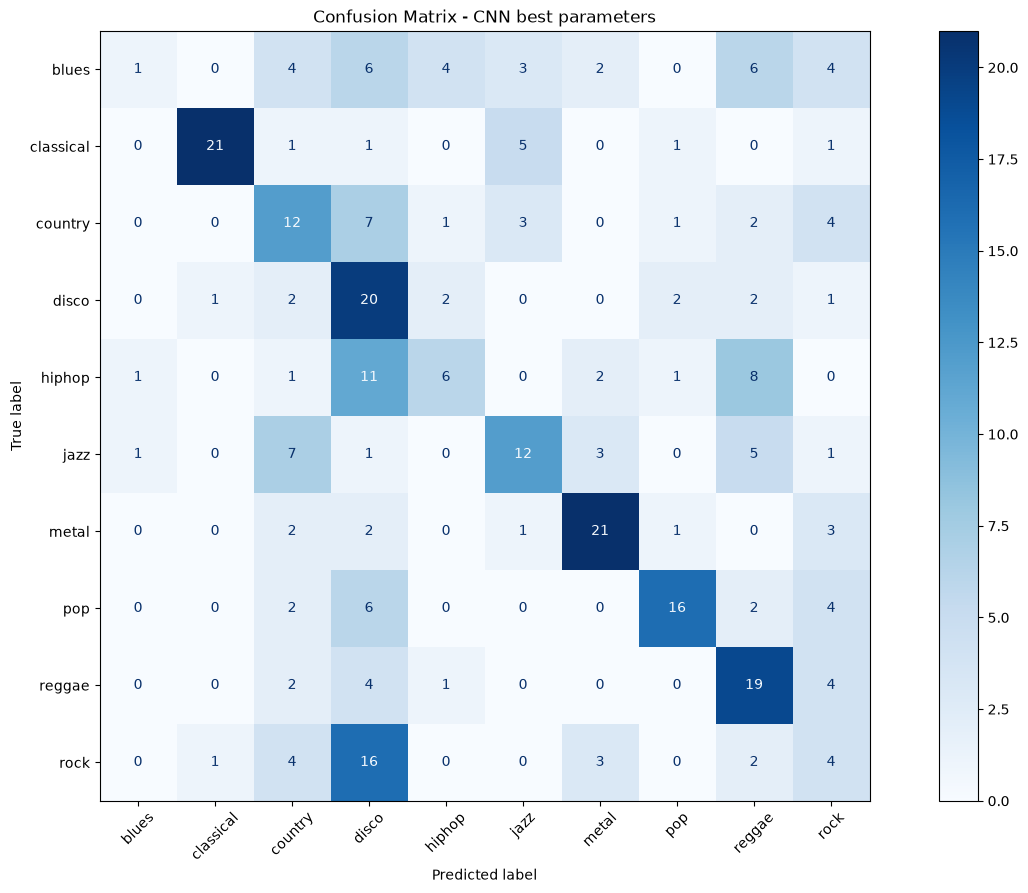

In [64]:
# test_size	random_state	padding	    optimizer	n_layers	input_size	dropout_n	dropout	density	batch_size	epochs	loss	  accuracy
# 0.4	        0	        valid	    rmsprop	      2	            200	        0.25	True	 512	32	           10	1.299798	0.547500
# 0.3	        0	        same	    adam	        3	        200	        0.25	True	 512	64	            10	1.572510	0.493333
# 0.4	42	valid	adam	2	150	0.25	True	512	64	10	1.681296	0.395000
#model-1#test_size = 0.1; random_state = 0; padding = "same"; optimizer = "adam"; n_layers= 3; input_size = 288; dropout_n = 0.25; dropout = False; density = 512; batch_size =64; EPOCHS = 30
#model-2#test_size = 0.4; random_state = 99; padding = "valid"; optimizer = "adam"; n_layers= 2; input_size = 200; dropout_n = 0.25; dropout = False; density = 512; batch_size =32; EPOCHS = 30
#model-3#test_size = 0.2; random_state = 99; padding = "same"; optimizer = "rmsprop"; n_layers= 2; input_size = 200; dropout_n = 0.25; dropout = True; density = 256; batch_size =32; EPOCHS = 30
test_size = 0.3; random_state = 42; padding = "valid"; optimizer = "rmsprop"; n_layers= 3; input_size = 200; dropout_n = 0.50; dropout = True; density = 256; batch_size =64; EPOCHS = 30
#model-5#test_size = 0.3; random_state = 0; padding = "valid"; optimizer = "adam"; n_layers= 3; input_size = 288; dropout_n = 0.25; dropout = False; density = 256; batch_size =64; EPOCHS = 30
#test_size = 0.4; random_state = 0; padding = "valid"; optimizer = "rmsprop"; n_layers= 2; input_size = 200; dropout_n = 0.25; dropout = True; density = 512; batch_size =32
# test_size = 0.3; random_state = 0; padding = "same"; optimizer = "adam"; n_layers= 3; input_size = 200; dropout_n = 0.25; dropout = True; density = 512; batch_size =64
# test_size = 0.4; random_state = 42; padding = "valid"; optimizer = "adam"; n_layers= 2; input_size = 150; dropout_n = 0.25; dropout = True; density = 512; batch_size =64

EPOCHS = 30

def load_images_at_size(input_size):
    if input_size in image_cache:
        return image_cache[input_size]
    X_images = []
    for image_path in image_paths:
        img = load_img(image_path, target_size=(input_size, input_size))
        X_images.append(img_to_array(img) / 255.0) # to normalize
    X = np.array(X_images)
    y_cat_local = to_categorical(y_enc)
    image_cache[input_size] = (X, y_cat_local)
    return X, y_cat_local

X, y_cat = load_images_at_size(input_size)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size = test_size,
    random_state=random_state,
    stratify = y_enc
)

###

model_layers = [
    tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding=padding,
                        input_shape = (input_size, input_size, 3)),
    tf.keras.layers.MaxPool2D(2,2),                               
]

if dropout:
    model_layers.append(tf.keras.layers.Dropout(dropout_n))

model_layers.extend([
    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding = padding),
    tf.keras.layers.MaxPooling2D(2,2),
])

if dropout:
    model_layers.append(tf.keras.layers.Dropout(dropout_n))

if n_layers >= 3: ### 3rd layer
    model_layers.extend([
        tf.keras.layers.Conv2D(128, (3,3), activation = "relu", padding = padding),
        tf.keras.layers.MaxPooling2D(2,2),
    ])
    if dropout:
        model_layers.append(keras.layers.Dropout(dropout_n))

if n_layers >= 4: ### 4th layer
    model_layers.extend([
    tf.keras.layers.Conv2D(128, (3,3), activation = "relu", padding = padding),
    tf.keras.layers.MaxPooling2D(2,2),
])
    if dropout:
        model_layers.append(keras.layers.Dropout(dropout_n))

model_layers.append(tf.keras.layers.Flatten())
model_layers.append(tf.keras.layers.Dense(density, activation="relu"))

if dropout:
    model_layers.append(tf.keras.layers.Dropout(dropout_n))

model_layers.append(tf.keras.layers.Dense(10, activation = "softmax"))
model = tf.keras.Sequential(model_layers)
model.compile(optimizer=optimizer,
            loss = "categorical_crossentropy",
            metrics = ["accuracy"])

history = model.fit(X_train, y_train, epochs = EPOCHS, batch_size = batch_size,
        validation_data = (X_test, y_test,), verbose = 1)

loss, acc = model.evaluate(X_test, y_test, verbose =1)

### generating a confusion matrix of the (best) model

y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)
displ = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= encoder.classes_)

fig, ax = plt.subplots(figsize=(18,10))
displ.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - CNN best parameters")
plt.show()

In [65]:
print("Accuracy:" , acc)

Accuracy: 0.4399999976158142


Plotting the models' performance to see if they're overfitting.

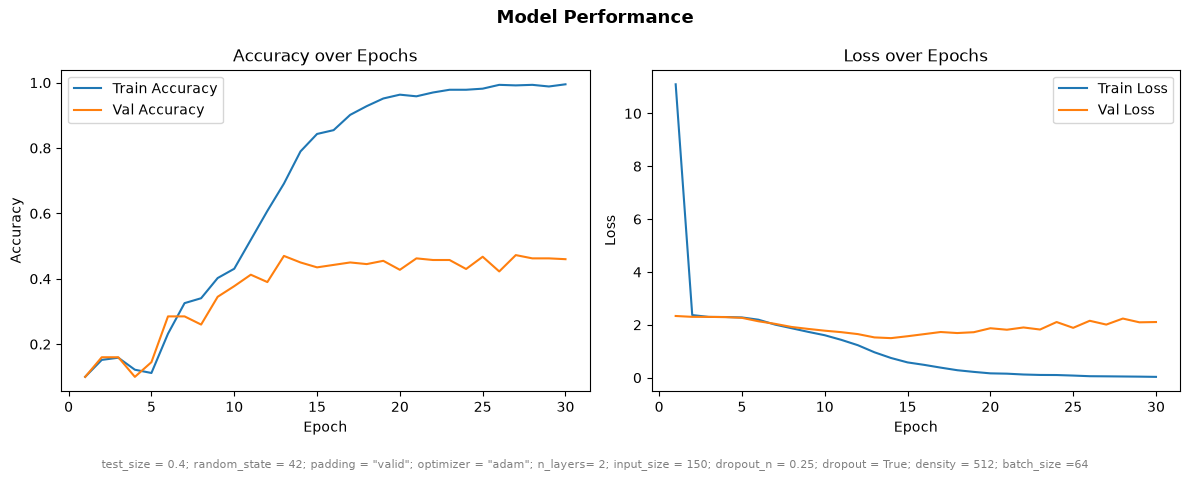

In [ ]:
# Printing graphs to vizualize overitting
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history['accuracy']) + 1)

config_str = (
    "test_size = 0.4; random_state = 42; padding = \"valid\"; optimizer = \"adam\"; n_layers= 2; input_size = 150; dropout_n = 0.25; dropout = True; density = 512; batch_size =64"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history.history['accuracy'], label='Train Accuracy')
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_title('Accuracy over Epochs')

axes[1].plot(epochs_range, history.history['loss'], label='Train Loss')
axes[1].plot(epochs_range, history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].set_title('Loss over Epochs')

fig.suptitle('Model Performance', fontsize=13, fontweight='bold')
fig.text(0.5, -0.02, config_str, ha='center', va='top', fontsize=8, color='gray', wrap=True)

plt.tight_layout()
plt.savefig("cnn-model-8.png", bbox_inches='tight', dpi=150)
plt.show()

Most of them show signs of overfitting.

# ANN
Artificial Neural Networks are composed of layers of nodes (neurons), where each node processes an input value and passes the result on to the next layer. In this project, the input and hidden layers use the `ReLU` activation function to pass their values forward, while the output layer uses `Softmax` to produce a final class prediction across the 10 genres.
As with the CNN model, `ParameterSampler` was used to randomly generate a number of different hyperparameter configurations to train and evaluate, rather than exhaustively testing every possible combination. The parameters varied across runs include: the test size, the random seed, the number of hidden layers, the number of neurons per layer, whether dropout is applied and at what rate, the batch size, and the optimizer function. As with the CNN, `TensorFlow` was used to build and train the ANN.
During this initial sweep, each configuration was trained for only 10 epochs, in order to keep the overall search computationally feasible across a large number of configurations. Once the best-performing configuration was identified, it was retrained for 30 epochs to obtain a more accurate final evaluation of its performance.

### ANN - Data Collection

In [86]:
### Vars
param_grid = {
    "test_size": [0.2, 0.3, 0.4],
    "random_state": [0, 42, 99],
    "n_layers": [2, 3, 4],
    "neuro_1": [128, 256, 512],
    "neuro_2": [64, 128, 256],
    "neuro_3": [32, 64, 128],
    "neuro_4": [16, 32, 64],
    "dropout": [True, False],
    "dropout_n": [0.25, 0.5],
    "batch_size": [32, 64, 128],
    "optimizer": ["adam", "rmsprop"],
}
###
EPOCHS = 10
N_TRIALS = 50
CSV_PATH_ANN = "ann-data-extr.csv"
sampled_params = list(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=42))
###
df_extr = pd.read_csv("extracted-features.csv")
df_base = df_extr.copy() # df_3; df_30; extr_df
col = df_base.pop("genre") # "genre" for the extracted features one
df_base.insert(0, "genre", col)
df_base.drop("filename", inplace=True, axis=1)

X = df_base.drop(["genre"], axis =1)
y = df_base["genre"]

encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)
y_cat = to_categorical(y_enc)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

if not os.path.exists(CSV_PATH_ANN):

    results = []
    sampled_params = sorted(sampled_params, key=lambda d: d["batch_size"])

    for params in tqdm(sampled_params):

        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y_cat,
            test_size=params["test_size"],
            random_state=params["random_state"],
            stratify=y_enc
        )

        model_layers = [
            tf.keras.layers.Dense(params["neuro_1"], activation="relu",
                                   input_shape=(X_train.shape[1],)),
        ]

        if params["dropout"]:
            model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))

        model_layers.append(tf.keras.layers.Dense(params["neuro_2"], activation="relu"))

        if params["dropout"]:
            model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))

        if params["n_layers"] >= 3: 
            model_layers.append(tf.keras.layers.Dense(params["neuro_3"], activation="relu"))
            if params["dropout"]:
                model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))

        if params["n_layers"] >= 4:  
            model_layers.append(tf.keras.layers.Dense(params["neuro_4"], activation="relu"))
            if params["dropout"]:
                model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))

        model_layers.append(tf.keras.layers.Dense(10, activation="softmax"))

        model = tf.keras.Sequential(model_layers)
        model.compile(optimizer=params["optimizer"],
                      loss="categorical_crossentropy",
                      metrics=["accuracy"])

        model.fit(X_train, y_train,
                  epochs=EPOCHS,
                  batch_size=params["batch_size"],
                  validation_data=(X_test, y_test,),
                  verbose=0)

        loss, acc = model.evaluate(X_test, y_test, verbose=0)

        results.append({**params, "EPOCHS": EPOCHS, "LOSS": loss, "ACCURACY": acc})

        pd.DataFrame(results).to_csv(CSV_PATH_ANN, index=False)
print("File [", CSV_PATH_ANN,"] detected.")

File [ ann-data-extr.csv ] detected.


In [87]:
df_ann = pd.read_csv("ann-data-extr.csv") # ann-data-3s.csv  ann-data-30s.csv ann-data-extr.csv
df_ann = df_ann[df_ann["test_size"] != 0.2]
df_ann = df_ann[df_ann["dropout"] != False]
df_ann_sorted = df_ann.sort_values(by="ACCURACY", ascending=False)

df_ann_sorted.head(10)

,test_size,random_state,optimizer,neuro_4,neuro_3,neuro_2,neuro_1,n_layers,dropout_n,dropout,batch_size,EPOCHS,LOSS,ACCURACY
41,0.3,0,adam,32,64,256,512,3,0.25,True,128,10,1.002720,0.680000
11,0.4,0,rmsprop,64,128,128,512,3,0.25,True,32,10,0.961385,0.672500
9,0.3,0,adam,32,128,256,256,2,0.50,True,32,10,0.995937,0.663333
16,0.3,0,rmsprop,64,128,64,256,4,0.25,True,32,10,1.052328,0.650000
7,0.3,42,rmsprop,16,128,128,256,2,0.25,True,32,10,1.038411,0.646667
1,0.4,42,rmsprop,64,32,256,256,2,0.25,True,32,10,1.075066,0.640000
14,0.3,99,adam,32,128,128,512,2,0.25,True,32,10,1.018996,0.626667
30,0.4,99,rmsprop,16,128,256,256,2,0.25,True,64,10,1.073916,0.615000
6,0.4,0,rmsprop,16,64,128,128,3,0.25,True,32,10,1.133287,0.610000
25,0.4,42,adam,16,32,256,256,3,0.25,True,64,10,1.248662,0.605000


These accuracies look pretty high right now. The most accurate seems to be the ANN on the 3s data, in second place the ANN on the 30s data and last is the ANN on the extracted data.
Now onto training the top results for 30 epochs and print the confusion matrix.

Epoch 1/30


c:\Users\ket\Desktop\Jupyter-ML\Jupyter-ML\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5686 - loss: 1.2457 - val_accuracy: 0.7294 - val_loss: 0.8448
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7067 - loss: 0.8530 - val_accuracy: 0.7714 - val_loss: 0.6855
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7573 - loss: 0.7092 - val_accuracy: 0.7908 - val_loss: 0.6105
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7916 - loss: 0.6142 - val_accuracy: 0.8168 - val_loss: 0.5526
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8112 - loss: 0.5456 - val_accuracy: 0.8362 - val_loss: 0.4964
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8307 - loss: 0.4926 - val_accuracy: 0.8515 - val_loss: 0.4621
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8478 - loss: 0.4388 - val_accuracy: 0.8529 - val_loss: 0.4567
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8652 - loss: 0.3967 - val_accuracy: 0.8565 - val_

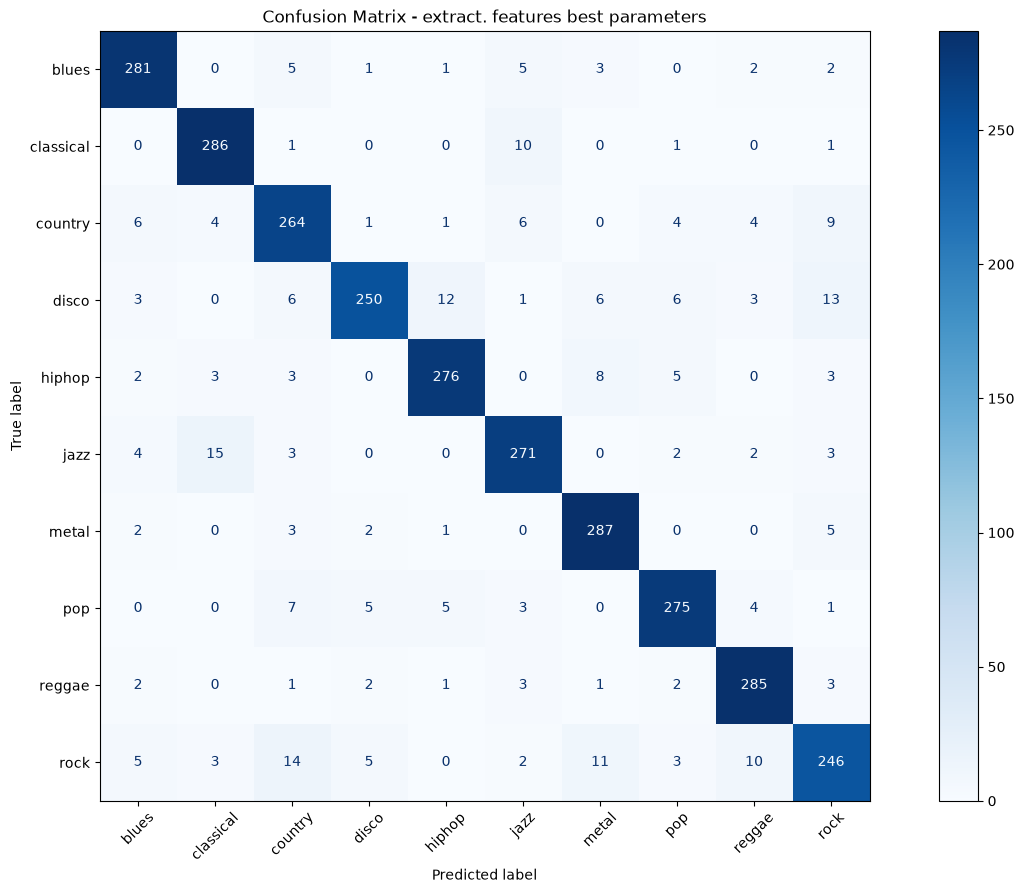

In [59]:
#test_size	random_state	optimizer	neuro_4	neuro_3	neuro_2	neuro_1	n_layers	dropout_n	dropout	batch_size	EPOCHS	LOSS	ACCURACY
# 3s
# 0.3	        99	            adam	    32	   128	 128	 512	  2	            0.25	True	 32	        10	   0.382703  0.872539
# 0.3	        0	            adam    	32  	64    256	 512	  3         	0.25	True	128	        10	   0.456358	 0.844177
# 0.4	        0	           rmsprop	    64  	128  128	512	      3	            0.25	True	32	        10     0.486971	 0.841592
# 0.4	        99	           rmsprop	    16  	128  256	256	      2	            0.25	True	64	        10     0.479124	 0.837087
# 0.4	        42	           rmsprop	    64  	32   256	256	      2	            0.25	True	32	        10     0.524728	 0.834835
test_size = 0.3; random_state = 99; optimizer = "adam"; neuro_4 = 32; neuro_3 = 128; neuro_2 = 128; neuro_1 = 512; n_layers = 2; dropout_n = 0.25; dropout = True; batch_size = 32
# test_size = 0.3; random_state = 0; optimizer = "adam"; neuro_4 = 32; neuro_3 = 64; neuro_2 = 256; neuro_1 = 512; n_layers = 3; dropout_n = 0.25; dropout = True; batch_size = 128
# test_size = 0.4; random_state = 0; optimizer = "rmsprop"; neuro_4 = 64; neuro_3 = 128; neuro_2 = 128; neuro_1 = 512; n_layers = 3; dropout_n = 0.25; dropout = True; batch_size = 128
# test_size = 0.4; random_state = 99; optimizer = "rmsprop"; neuro_4 = 16; neuro_3 = 128; neuro_2 = 256; neuro_1 = 256; n_layers = 2; dropout_n = 0.25; dropout = True; batch_size = 64
# test_size = 0.4; random_state = 42; optimizer = "rmsprop"; neuro_4 = 64; neuro_3 = 32; neuro_2 = 256; neuro_1 = 256; n_layers = 2; dropout_n = 0.25; dropout = True; batch_size = 32
# 30s
# 0.3	        42  	        rmsprop 	16  	128 	128 	256 	2   	    0.25	True	32	         10 	0.765892	0.753333
# 0.3	        0	            adam	    32	    64	    256 	512	    3	        0.25	True	128	         10	    0.817098	0.750000
# 0.3	        0	            adam	    32	    128	    256 	256	    2	        0.50	True	32	         10	    0.784100	0.753333
# 0.4	        0	            rmsprop	    64	    128	    128	    512	    3	        0.25	True	32	         10 	0.769928	0.740000
# 0.3	        99	            adam	    32	    128	    128	    512	    2	        0.25	True	32	         10 	0.804967	0.723333
# test_size = 0.3; random_state = 42; optimizer = "rmsprop"; neuro_4 = 16; neuro_3 = 128; neuro_2 = 128; neuro_1 = 256; n_layers = 2; dropout_n = 0.25; dropout = True; batch_size = 32
# test_size = 0.3; random_state = 0; optimizer = "adam"; neuro_4 = 32; neuro_3 = 64; neuro_2 = 256; neuro_1 = 512; n_layers = 3; dropout_n = 0.25; dropout = True; batch_size = 128
# 👑 test_size = 0.3; random_state = 0; optimizer = "adam"; neuro_4 = 32; neuro_3 = 128; neuro_2 = 256; neuro_1 = 256; n_layers = 2; dropout_n = 0.50; dropout = True; batch_size = 32
# test_size = 0.4; random_state = 0; optimizer = "rmsprop"; neuro_4 = 64; neuro_3 = 128; neuro_2 = 128; neuro_1 = 512; n_layers = 3; dropout_n = 0.25; dropout = True; batch_size = 32
# test_size = 0.3; random_state = 99; optimizer = "adam"; neuro_4 = 32; neuro_3 = 128; neuro_2 = 128; neuro_1 = 512; n_layers =2; dropout_n = 0.25; dropout = True; batch_size = 32
# extracted features
# 0.3	        0	            adam	    32	    64	    256	    512 	3       	0.25	True	128     	10  	1.002720	0.680000
# 0.4	        0	            rmsprop	    64	    128	    128	    512 	3       	0.25	True	32      	10  	0.961385	0.672500
# 0.3	        0	            adam	    32	    128	    256	    256 	2       	0.50	True	32      	10  	0.995937	0.663333
# 0.3	        0	            rmsprop	    64	    128	    64	    256 	4       	0.25	True	32      	10  	1.052328	0.650000
# 0.3	        42	            rmsprop	    16	    128	    128	    256 	2       	0.25	True	32      	10  	1.038411	0.646667
# test_size = 0.3; random_state = 0; optimizer = "adam"; neuro_4 = 32; neuro_3 = 64; neuro_2 = 256; neuro_1 = 512; n_layers = 3; dropout_n = 0.25; dropout = True; batch_size = 128
# test_size = 0.4; random_state = 0; optimizer = "rmsprop"; neuro_4 = 64; neuro_3 = 128; neuro_2 = 128; neuro_1 = 512; n_layers = 3; dropout_n = 0.25; dropout = True; batch_size = 32
# 👑 test_size = 0.3; random_state = 0; optimizer = "adam"; neuro_4 = 32; neuro_3 = 128; neuro_2 = 256; neuro_1 = 256; n_layers = 2; dropout_n = 0.50; dropout = True; batch_size = 32
# test_size = 0.3; random_state = 0; optimizer = "rmsprop"; neuro_4 = 64; neuro_3 = 128; neuro_2 = 64; neuro_1 = 256; n_layers = 4; dropout_n = 0.25; dropout = True; batch_size = 32
# test_size = 0.3; random_state = 42; optimizer = "rmsprop"; neuro_4 = 16; neuro_3 = 128; neuro_2 = 128; neuro_1 = 256; n_layers =2; dropout_n = 0.25; dropout = True; batch_size = 32


EPOCHS = 30
# CSV_PATH_ANN = "ann-data-extr.csv"
sampled_params = list(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=42))
###
# df_extr = pd.read_csv("ann-data-extr.csv") # ann-data-extr.csv
df_base = df_3.copy() # df_3; df_30; extr_df
col = df_base.pop("label") # "genre" for the extracted features one
df_base.insert(0, "label", col)
df_base.drop("filename", inplace=True, axis=1)

X = df_base.drop(["label"], axis =1)
y = df_base["label"]

encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)
y_cat = to_categorical(y_enc)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

results = []

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat,
    test_size=test_size,
    random_state=random_state,
    stratify=y_enc
)


model_layers = [
    tf.keras.layers.Dense(neuro_1, activation="relu",
                            input_shape=(X_train.shape[1],)),
]

if dropout:
    model_layers.append(tf.keras.layers.Dropout(dropout_n))

model_layers.append(tf.keras.layers.Dense(neuro_2, activation="relu"))

if dropout:
    model_layers.append(tf.keras.layers.Dropout(dropout_n))

if dropout >= 3: 
    model_layers.append(tf.keras.layers.Dense(neuro_3, activation="relu"))
    if dropout:
        model_layers.append(tf.keras.layers.Dropout(dropout_n))

if dropout >= 4:  
    model_layers.append(tf.keras.layers.Dense(neuro_4, activation="relu"))
    if dropout:
        model_layers.append(tf.keras.layers.Dropout(dropout_n))

model_layers.append(tf.keras.layers.Dense(10, activation="softmax"))

model = tf.keras.Sequential(model_layers)
model.compile(optimizer=optimizer,
                loss="categorical_crossentropy",
                metrics=["accuracy"])

history = model.fit(X_train, y_train,
            epochs=EPOCHS,
            batch_size=batch_size,
            validation_data=(X_test, y_test,),
            verbose=1)

loss, acc = model.evaluate(X_test, y_test, verbose=1)

### generating a confusion matrix of the (best) model

y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)
displ = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= encoder.classes_)

fig, ax = plt.subplots(figsize=(18,10))
displ.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - extract. features best parameters")
plt.show()

In [ ]:
print("Accuracy:" , acc)
# 3s:   Accuracy: 0.9079079031944275
# 30s:  Accuracy: 0.7766666412353516
# extr: Accuracy: 0.7166666388511658

Accuracy: 0.9079079031944275


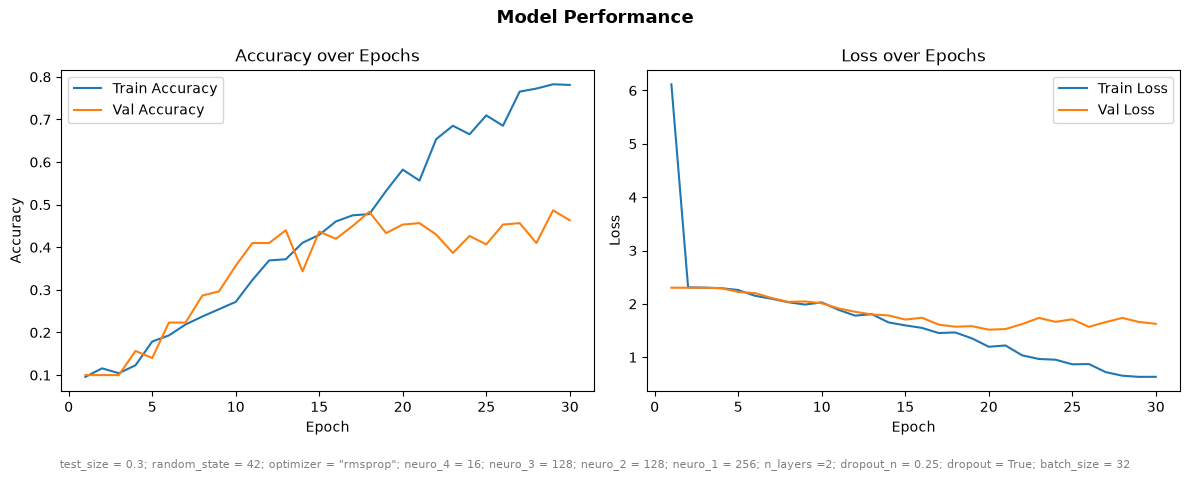

In [ ]:
epochs_range = range(1, len(history.history['accuracy']) + 1)

config_str = (
    "test_size = 0.3; random_state = 42; optimizer = \"rmsprop\"; neuro_4 = 16; neuro_3 = 128; neuro_2 = 128; neuro_1 = 256; n_layers =2; dropout_n = 0.25; dropout = True; batch_size = 32"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history.history['accuracy'], label='Train Accuracy')
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_title('Accuracy over Epochs')

axes[1].plot(epochs_range, history.history['loss'], label='Train Loss')
axes[1].plot(epochs_range, history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].set_title('Loss over Epochs')

fig.suptitle('Model Performance', fontsize=13, fontweight='bold')

# config description
fig.text(0.5, -0.02, config_str, ha='center', va='top', fontsize=8, color='gray', wrap=True)

plt.tight_layout()
plt.savefig("ann-model-extr-6.png", bbox_inches='tight', dpi=150)
plt.show()

Here the graphs of the 5 strongest performing models were plotted to show the training and validation accuracies as well as training and validation losses across epochs, making it easier to see whether overfitting is taking place.

# Comparison & Findings

In addition to comparing the models' predictive accuracy, which is not enough to form an idea of how a model is performing, confusion matrices were used to better understand whether the model is making any mistakes in its guesses, and where. Training/validation graphs were plotted to check for overfitting. Overfitting is when a model learns the training data too well, including its noise, rather than the underlying patterns that generalize to new data. Overfitting is undesirable because it results in a model that performs well on data it has already seen but poorly on unseen data.

## kNN - Findings

Before getting into the restuls, it must be mentioned that while configurations using the test size of `0.1` and `0.2` reached slightly higher accuracies, they were ultimately excluded, as the size of the dataset is small - they were not deemed an acceptable value. 
Across the three feature sets, the kNN model reached prediction accuracies of `0.67` for the manually extracted features, `0.72` for the 30-second features, and `0.88` for the 3-second features. Two patterns stand out: the manually extracted features - which contain roughly half the number of columns compared to the other two feature sets - produced the lowest accuracy, which may suggest that the reduced feature set may be missing information that is visible in the other one. Second, the 3-second features, which benefit from roughly ten times more training data than the 30-second set, achieved noticeably higher accuracy, which shows that kNN is sensitive to the amount of available training data.

In [51]:
from IPython.display import HTML

imgs = ["knn-confusion-matrices/knn-confusion-matrix-3s.png",
        "knn-confusion-matrices/knn-confusion-matrix-30s.png",
        "knn-confusion-matrices/knn-confusion-matrix-extract.png"]

html = "".join(
    f'<img src="{img}" style="width:32%; display:inline-block; margin-right:0.1%;">'
    for img in imgs
)
HTML(html)


This pattern is also reflected in the respective confusion matrices. The 3-second feature set produces the cleanest diagonal, with the fewest and smallest mistakes. The 30-second feature set shows a visibly less clean diagonal, with mistakes more spread out across genres. The manually extracted features perform worse still, with several diagonal values noticeably weaker than in the other two matrices, which show a higher frequency of misclassification of the genres.
A concrete example consistent across the matrices is that `jazz` has a tendency to be classified as `classical`.

## ANN - Findings

The ANN was the best-performing of the three models, achieving prediction accuracies of approximately `0.90`, `0.77`, and `0.71` for the 3-second, 30-second, and manually extracted features respectively, while showing no definite signs of overfitting. Some configurations achieved even higher accuracy during the initial sweep, but were excluded from these findings after inspection of their training/validation performance graphs revealed clear overfitting.
Although data was also collected for configurations with `dropout = False`, only configurations that included dropout were ultimately considered, as models without dropout were generally observed to overfit. For the same reason discussed in the kNN section, results using a test size of `0.2` and `0.1` were also excluded, given the limited size of the dataset relative to the split.

In [88]:
imgs = ["ann-confusion-matrices/ann-confusion-matrix-3s.png",
        "ann-confusion-matrices/ann-confusion-matrix-30s.png",
        "ann-confusion-matrices/ann-confusion-matrix-extract.png"]

html = "".join(
    f'<img src="{img}" style="width:32%; display:inline-block; margin-right:0.1%;">'
    for img in imgs
)
HTML(html)

The confusion matrices show a clean, almost perfect diagonal for the 3-second feature set, with only a small number of mistakes - notably, a handful of `jazz` tracks misclassified as `classical`, similarly to the kNN. This is worth pointing out specifically because the 30-second and extracted-feature matrices do not follow the same pattern: instead, they each show a small but distinct set of their own mistakes. In the 30-second matrix, the most notable mistake is the reverse pairing - `classical` tracks being misclassified as `jazz`. In the extracted features matrix, the more prominent confusions instead involve `disco` and `reggae` tracks being misclassified as `hip-hop`.

In [89]:
imgs = ["graphs-ann-3s/ann-model-3s-1.png",
        "graphs-ann-30s/ann-model-30s-3.png",
        "graphs-ann-extr/ann-model-extr-3.png"]

html = "".join(
    f'<img src="{img}" style="width:75%; height:auto; display:block; margin:0 0 12px 0;">'
    for img in imgs
)
HTML(html)

The training and validation performance graphs show no strong signs of overfitting. Typically, overfitting manifests as training accuracy continuing to rise and training loss continuing to fall, all the while validation accuracy plateaus/declines and validation loss begins to increase; essentially a growing gap between the two curves. In the graphs produced for the selected configurations, training and validation curves instead remain relatively close to one another throughout training, with both metrics improving in a similar pattern, suggesting the models generalize reasonably well to unseen data.

## CNN - Findings

As with the kNN and ANN models, results using test sizes of `0.1` and `0.2` were excluded, despite data having been collected for them, for the same reasons discussed previously. Similarly, configurations with `dropout=False` were excluded from consideration: while these consistently reached higher accuracy scores, inspection of the corresponding training/validation graphs revealed that they were overfitting. Configurations with `dropout=True` were therefore used instead, though even among these, a number of configurations still showed some degree of overfitting.
The best-performing configuration found reached an accuracy of only `0.44`, notably lower than both the kNN and ANN models, and still showed signs of overfitting despite the use of dropout. This result was unexpected - going into the project, the CNN was anticipated to be the most accurate of the three models, given its ability to learn spatial patterns directly from the spectrogram images. A few possible explanations may account for this gap in performance. It is possible that the specific hyperparameters explored during the randomized search (input image size, number of convolutional layers, neuron density, optimizer, batch size, padding, and dropout rate) did not include a combination well-suited to this dataset, and that a wider or more targeted search may yield better results. It is also possible that the relatively small size of the GTZAN dataset limits how well a CNN, which typically benefits from large volumes of training data, can learn generalizable spatial patterns from spectrogram images. Further investigation, such as testing a larger range of architectures or applying data augmentation, could help clarify which of these factors is the primary cause.

In [90]:
imgs = ["cnn-confusion-matrix.png",
        "graphs-cnn/cnn-model-4.png"]

html = "".join(
    f'<img src="{img}" style="width:75%; height:auto; display:block;">'
    for img in imgs
)
HTML(html)

The confusion matrix shows the above described more clearly, the diagonal is split in half as the model fails to identify `hiphop` at all. `jazz` is misclassified as `country` more than half the time and `reggae` classified as `blues` are the most obvious mistakes.

In [91]:
imgs = ["graphs-cnn/cnn-model-1.png",
        "graphs-cnn/cnn-model-2.png",
        "graphs-cnn/cnn-model-3.png",
        "graphs-cnn/cnn-model-5.png",
        "graphs-cnn/cnn-model-6.png",
        "graphs-cnn/cnn-model-7.png"]

html = "".join(
    f'<img src="{img}" style="width:32%; display:inline-block; margin-right:0.1%;">'
    for img in imgs
)
HTML(html)

Additional performance graphs of a few different configurations that scored high on predicted accuracy but turn out to be overfitting.

 # Conclusion
 This project sets out to compare the performance of three machine learning approaches: kNN, an ANN, and a CNN; on the task of music genre classification using the GTZAN dataset. Across the tabular feature representations, both `kNN` and the `ANN` performed similarly well, achieving their best results on the 3-second feature set (`0.88` and `0.90` respectively), followed by the 30-second features, and finally the manually extracted features. This consistent pattern across two otherwise different models suggests that the accuracy differences observed were driven more by the amount and quality of the underlying data than by the choice of model itself.
The CNN, by contrast, performed noticeably worse than expected, reaching a best accuracy of only `0.44` despite the use of dropout and a broad hyperparameter search. This was a surprising result, given that CNNs are generally well-suited to image-based tasks and were anticipated to outperform the other two models. As discussed in the CNN findings, this gap is likely due to some combination of an insufficiently explored hyperparameter space and the comparatively small size of the GTZAN dataset relative to what CNNs typically require to learn robust spatial features.
Beyond just predictive accuracy, the confusion matrices provided additional insight into each model's behaviour, revealing recurring points of confusion - most notably between `jazz` and `classical` - that appeared across multiple models and feature representations. This suggests that some genre pairs share acoustically overlapping characteristics that are more difficult for some of these approaches to tell apart, regardless of the data representation used.
Overall, these results suggest that for genre classification on a modestly sized dataset like GTZAN, simpler models trained on well-engineered tabular audio features (such as kNN and the ANN) can be considerably more effective than a more complex CNN trained on raw spectrogram images. Future work could explore data augmentation and a more targeted or exhaustive hyperparameter search.

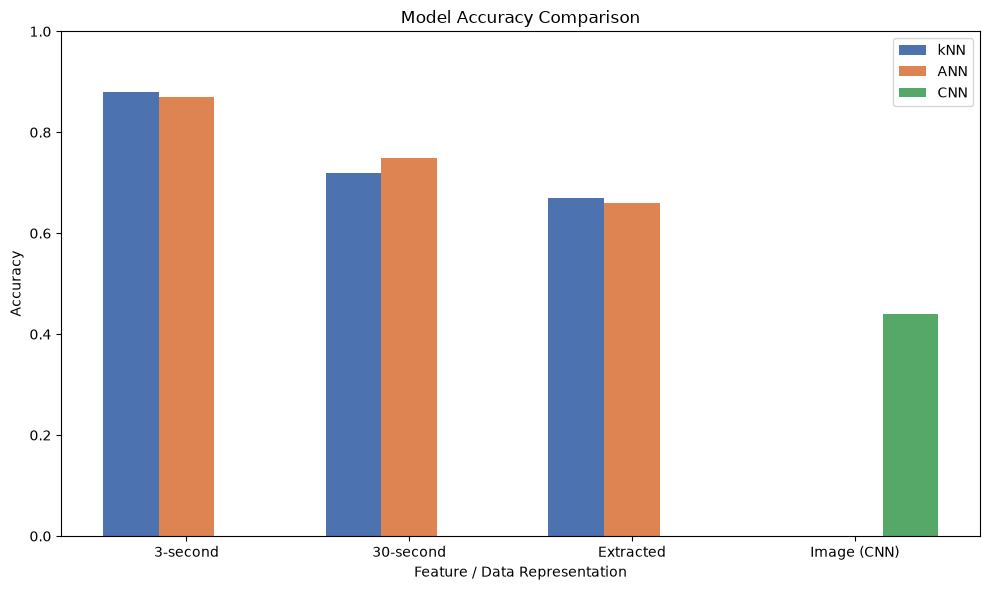

In [68]:
categories = ["3-second", "30-second", "Extracted", "CNN"]
knn_vals = [0.88, 0.72, 0.67, 0]   # 0 = not applicable
ann_vals = [0.90, 0.77, 0.71, 0]
cnn_vals = [0, 0, 0, 0.44]

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, knn_vals, width, label='kNN', color='#4C72B0')
ax.bar(x, ann_vals, width, label='ANN', color='#DD8452')
ax.bar(x + width, cnn_vals, width, label='CNN', color='#55A868')

ax.set_xlabel('Feature / Data Representation')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

# Sources

- Music information retrieval, [Wikipedia](https://en.wikipedia.org/wiki/Music_information_retrieval)
- GTZAN dataset, [Kaggle](https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/data)
- AudioFeaturizer, [PyPI](https://pypi.org/project/AudioFeaturizer/)
- Correlation Heatmap, [GeeksForGeeks](https://www.geeksforgeeks.org/python/how-to-create-a-seaborn-correlation-heatmap-in-python/)
- How to Visualise Correlations and Data With Heatmaps in Python, [Youtube](https://www.youtube.com/watch?v=J7cd1-g1O7A)
- K-Nearest Neighbor(KNN) Algorithm, [GeeksForGeeks](https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/)
- How to split a Dataset into Train and Test Sets using Python, [GeeksForGeeks](https://www.geeksforgeeks.org/machine-learning/how-to-split-a-dataset-into-train-and-test-sets-using-python/)
- KNeighborsClassifier, [Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) 
- The Importance of Feature Scaling in KNN, [GitHub](https://gao-hongnan.github.io/gaohn-galaxy/machine_learning/neighbours/k_nearest_neighbours/knn_feature_scaling.html) 25.6.26
- Neural network (machine learning), [Wikipedia](https://en.wikipedia.org/wiki/Neural_network_(machine_learning))
- Code your first Neural Network with TensorFlow, [Youtube](https://www.youtube.com/watch?v=VPlFpvLOgtQ)
- Convolutional Neural Network (CNN) in Tensorflow, [GeeksForGeeks](https://www.geeksforgeeks.org/deep-learning/convolutional-neural-network-cnn-in-tensorflow/) 
- ML Zero to Hero series by TensorFlow, [Youtube](https://www.youtube.com/watch?v=KNAWp2S3w94&list=PLQY2H8rRoyvwWuPiWnuTDBHe7I0fMSsfO)
- 2D Convolution Explained: Fundamental Operation in Computer Vision, [Youtube](https://www.youtube.com/watch?v=yb2tPt0QVPY)
- Introduction to Pooling Layer in CNN, [GeeksForGeeks](https://www.geeksforgeeks.org/deep-learning/introduction-to-pooling-layer-cnn/)
- Introduction to Artificial Neural Networks and its Applications, [GeeksForGeeks](https://www.geeksforgeeks.org/deep-learning/artificial-neural-networks-and-its-applications/)
- Module: tf.keras.optimizers, [TensorFlow](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers)
- What is a Confusion Matrix?, [Youtube](https://www.youtube.com/watch?v=bN-yBh4GAeY)
- A Complete Guide to Data Augmentation, [Datacamp](https://www.datacamp.com/tutorial/complete-guide-data-augmentation)
- Troubleshooting and sentence rephrasing, [Claude AI](https://claude.ai/)


